<a href="https://colab.research.google.com/github/RichaGaharwar/Aerofit---Descriptive-Statistics-Probability/blob/main/Aerofit_Descriptive_Statistics_%26_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Aerofit**
---



Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.

---

**Business Problem**

---

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.


*   Perform descriptive analytics to create a customer profile for each AeroFit treadmill product by developing appropriate tables and charts.

*   For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their  insights/impact on the business.


---
**Product Portfolio:**

---

*   The KP281 is an entry-level treadmill that sells for $1,500.

*   The KP481 is for  mid-level runners that sell for $1,750.

*   The KP781 treadmill is having advanced features that sell for $2,500.
---


---


**What good looks like?**


---

* Import the dataset and do usual data analysis steps like
  * checking the structure & characteristics of the dataset

  * Detect Outliers (using boxplot, “describe” method by checking the difference between mean and median)
  * Check if features like marital status, age have any effect on the product purchased (using countplot, histplots, boxplots etc)

  * Representing the marginal probability like - what percent of customers have purchased KP281, KP481, or KP781 in a table (can use pandas.crosstab here)

  * Check correlation among different factors using heat maps or pair plots.

* With all the above steps you can answer questions like:

  * What is the probability of a male customer buying a KP781 treadmill?

  * Customer Profiling - Categorization of users.

  * Probability- marginal, conditional probability.

  * Some recommendations and actionable insights, based on the inferences.

* Later on, we will see more ways to do “customer segmentation”, but this case study in itself is relevant in some real-world scenarios.


---


**Evaluation Criteria**


---


* Defining Problem Statement and Analysing basic metrics (10 Points)

  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary

* Non-Graphical Analysis: Value counts and unique attributes ​​(10 Points)

* Visual Analysis - Univariate & Bivariate (30 Points)

  * For continuous variable(s): Distplot, countplot, histogram for univariate analysis (10 Points)
  * For categorical variable(s): Boxplot (10 Points)
  * For correlation: Heatmaps, Pairplots(10 Points)

* Missing Value & Outlier Detection (10 Points)
* Business Insights based on Non-Graphical and Visual Analysis (10 Points)
  * Comments on the range of attributes
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plot

* Recommendations (10 Points) - Actionable items for business. No technical jargon. No complications. Simple action items that everyone can understand


---



In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

aerofit = pd.read_csv('/content/aerofit_data.csv')
aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


# **Exploratory Data Analysis**

In [55]:
aerofit.shape

(180, 9)

In [56]:
aerofit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [57]:
aerofit.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [58]:
aerofit['Product'].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


In [59]:
pd.crosstab(aerofit['Product'], aerofit['Gender'])

Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


In [60]:
pd.crosstab(aerofit['Product'], aerofit['MaritalStatus'])

MaritalStatus,Partnered,Single
Product,,
KP281,48,32
KP481,36,24
KP781,23,17


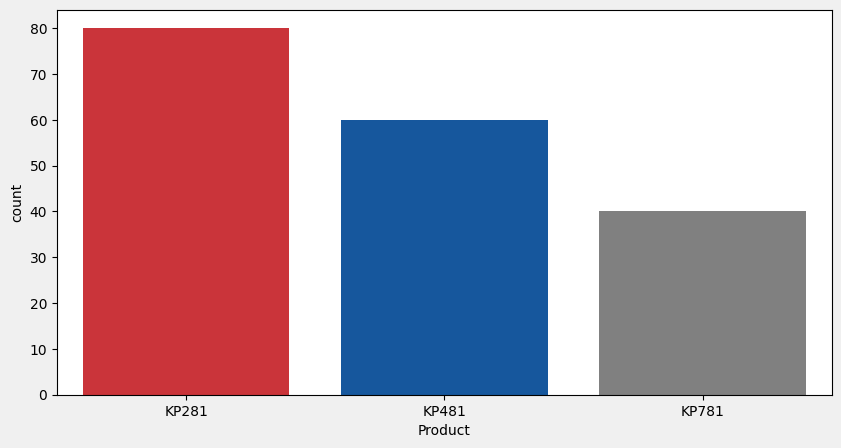

In [61]:
aerofit_palette = ['#E31B23', '#0056B3', '#808080']
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.countplot(data = aerofit, x = 'Product', hue = 'Product', palette = aerofit_palette, legend= False)
plt.show()

In [62]:
aerofit['Age'].value_counts().sort_index()

,count
Age,
18,1
19,4
20,5
21,7
22,7
23,18
24,12
25,25
26,12


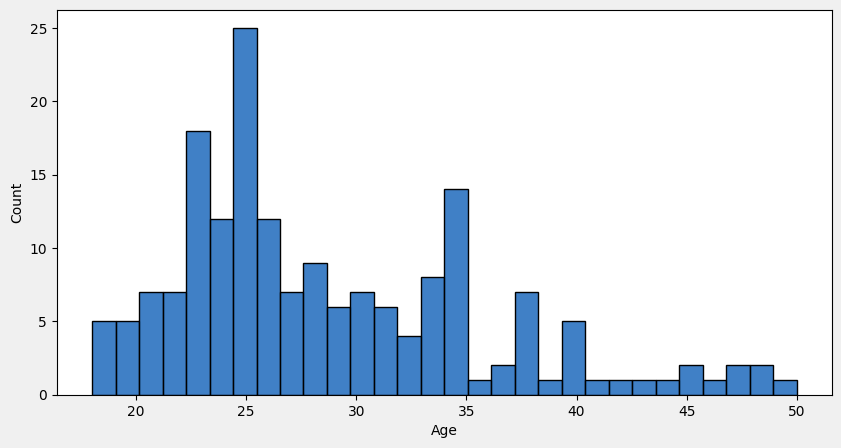

In [63]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.histplot(aerofit['Age'], bins=30, color = '#0056B3')
plt.show()

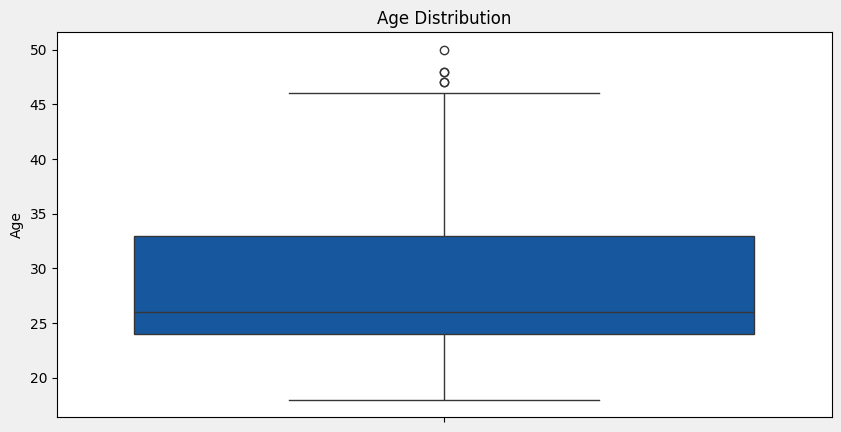

In [64]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.boxplot(aerofit['Age'], color = '#0056B3')
plt.title('Age Distribution')
plt.show()

In [65]:
aerofit['Gender'].value_counts()

,count
Gender,
Male,104
Female,76


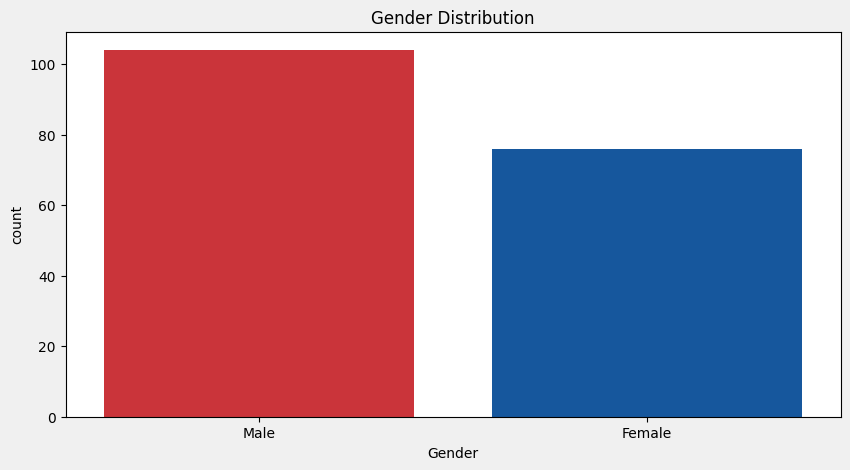

In [66]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.countplot(data = aerofit, x = 'Gender', hue = 'Gender', palette = aerofit_palette, legend= False)
plt.title('Gender Distribution')
plt.show()

In [67]:
aerofit['Education'].value_counts().sort_index()

,count
Education,
12,3
13,5
14,55
15,5
16,85
18,23
20,1
21,3


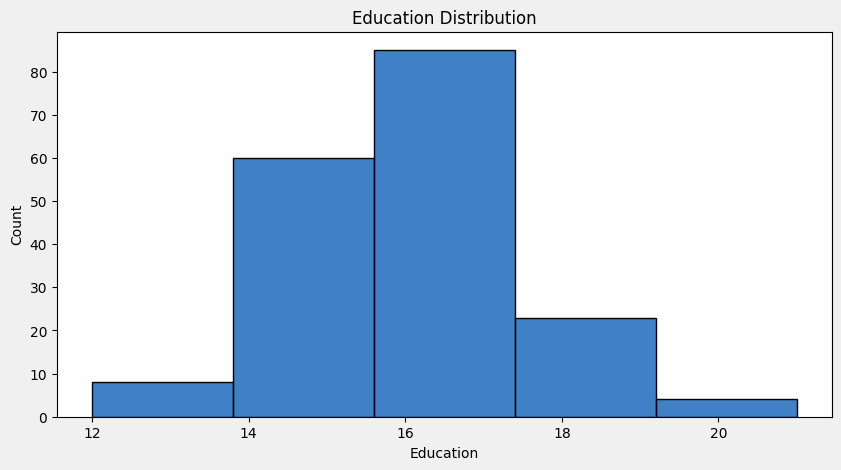

In [68]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.histplot(aerofit['Education'],bins=5, color = '#0056B3')
plt.title('Education Distribution')
plt.show()

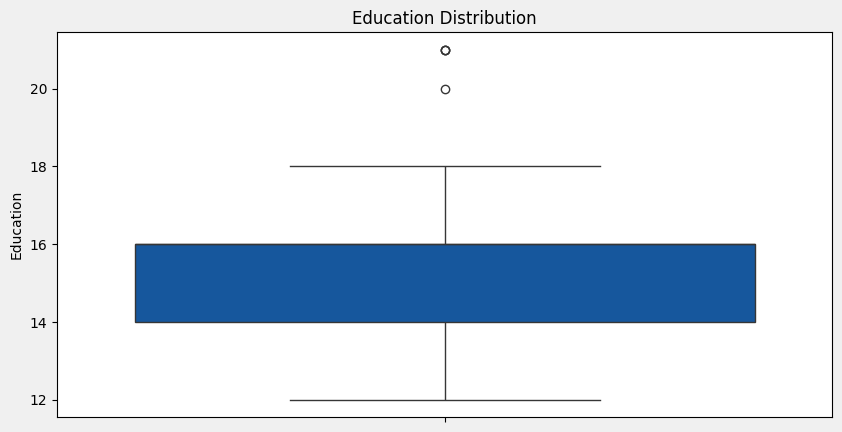

In [69]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.boxplot(aerofit['Education'], color = '#0056B3')
plt.title('Education Distribution')
plt.show()

In [70]:
aerofit['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,107
Single,73


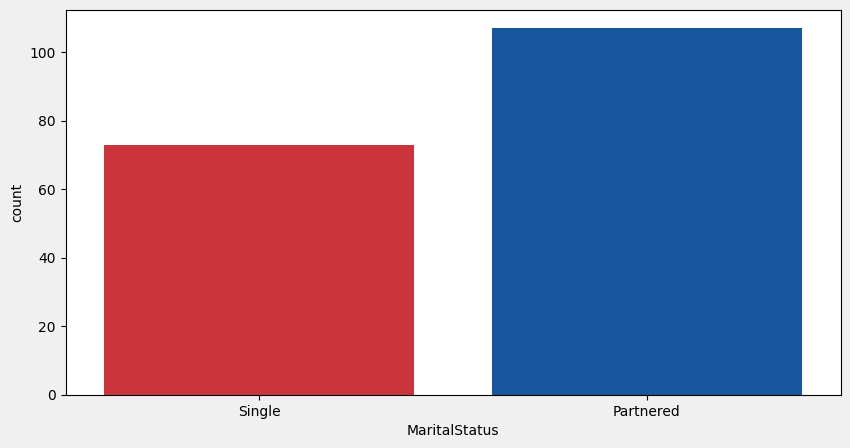

In [71]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.countplot(data = aerofit, x= 'MaritalStatus', hue = 'MaritalStatus', palette = aerofit_palette, legend= False)
plt.show()

In [72]:
aerofit['Usage'].value_counts().sort_index()

,count
Usage,
2,33
3,69
4,52
5,17
6,7
7,2


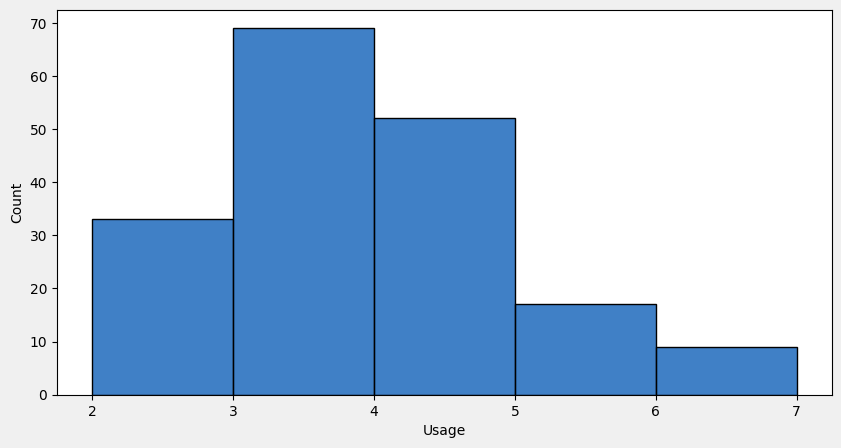

In [73]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.histplot(aerofit['Usage'], bins = 5, color = '#0056B3')
plt.show()

In [74]:
aerofit['Fitness'].value_counts().sort_index()

,count
Fitness,
1,2
2,26
3,97
4,24
5,31


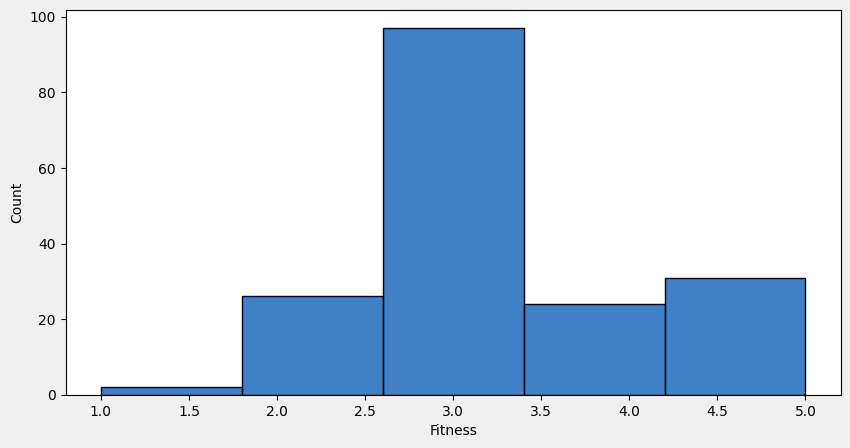

In [75]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.histplot(aerofit['Fitness'],bins = 5, color = '#0056B3')
plt.show()

In [76]:
aerofit['Income'].value_counts()

,count
Income,
45480,14
52302,9
53439,8
54576,8
46617,8
...,...
85906,1
99601,1
103336,1


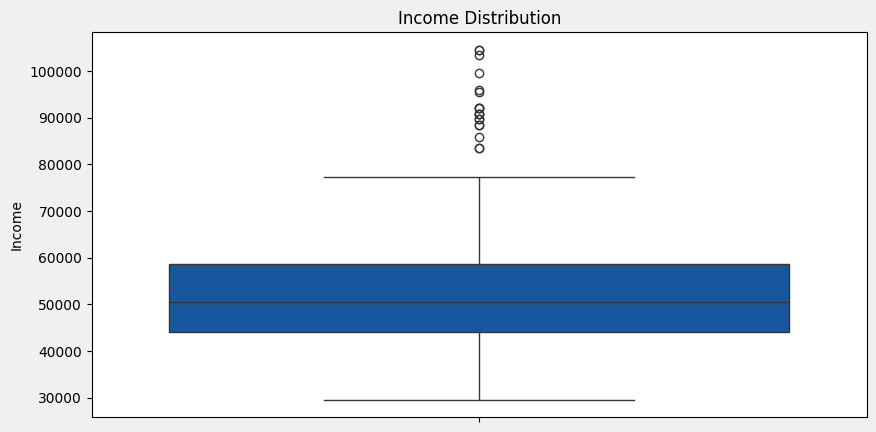

In [77]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.boxplot(aerofit['Income'], color = '#0056B3')
plt.title('Income Distribution')
plt.show()

In [78]:
aerofit['Miles'].value_counts().sort_index()

,count
Miles,
21,1
38,3
42,4
47,9
53,7
56,6
64,6
66,10
74,3


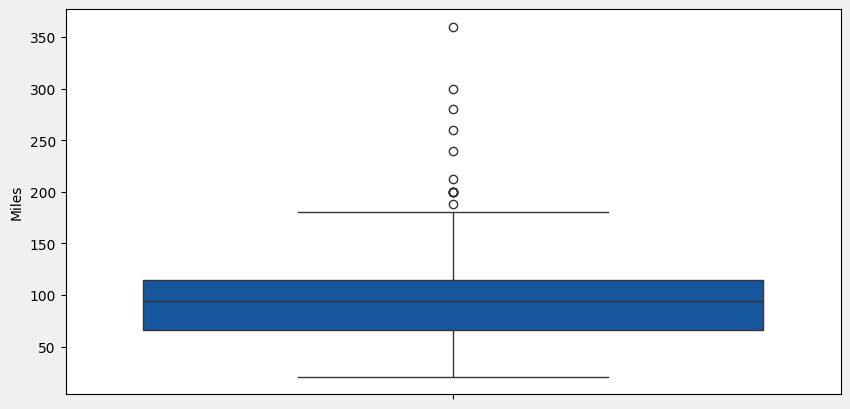

In [79]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.boxplot(aerofit['Miles'], color = '#0056B3')
plt.show()

Aerofit Red
HEX: #E31B23 or #FF0000

Aerofit Blue
HEX: #0056B3

Aerofit White
HEX: #FFFFFF

Aerofit Black
HEX: #111111

Aerofit Grey
HEX: #808080

# **Customer Baseline Profile for KP281**

In [80]:
KP281_DF = aerofit[aerofit['Product'] == 'KP281']
KP281_DF.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [81]:
KP281_DF.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,80.000000,80.000000,80.000000,80.00000,80.00000,80.000000
mean,28.550000,15.037500,3.087500,2.96250,46418.02500,82.787500
std,7.221452,1.216383,0.782624,0.66454,9075.78319,28.874102
min,18.000000,12.000000,2.000000,1.00000,29562.00000,38.000000
25%,23.000000,14.000000,3.000000,3.00000,38658.00000,66.000000
50%,26.000000,16.000000,3.000000,3.00000,46617.00000,85.000000
75%,33.000000,16.000000,4.000000,3.00000,53439.00000,94.000000
max,50.000000,18.000000,5.000000,5.00000,68220.00000,188.000000


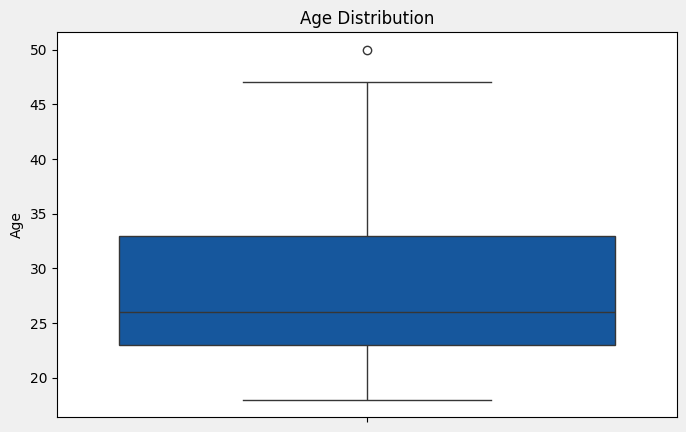

In [82]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Age'], color = '#0056B3')
plt.title('Age Distribution')
plt.show()

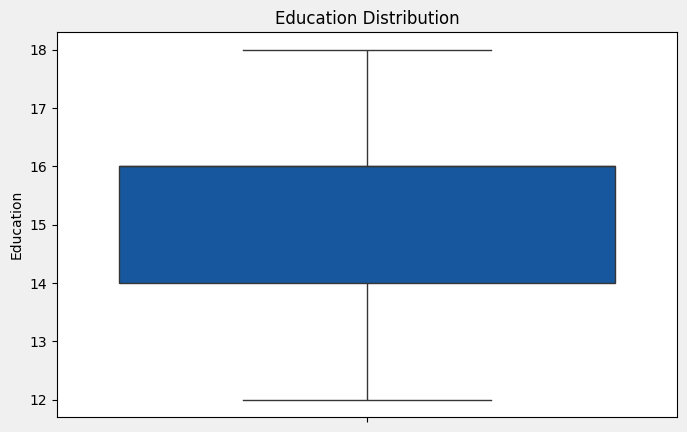

In [83]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Education'], color = '#0056B3')
plt.title('Education Distribution')
plt.show()

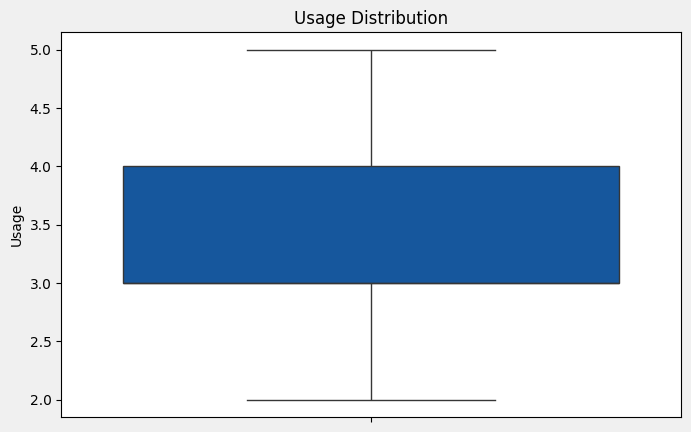

In [84]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Usage'], color = '#0056B3')
plt.title('Usage Distribution')
plt.show()

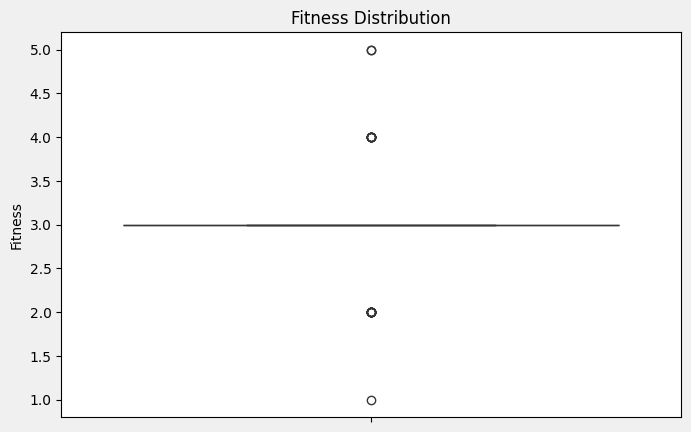

In [85]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Fitness'], color = '#0056B3')
plt.title('Fitness Distribution')
plt.show()

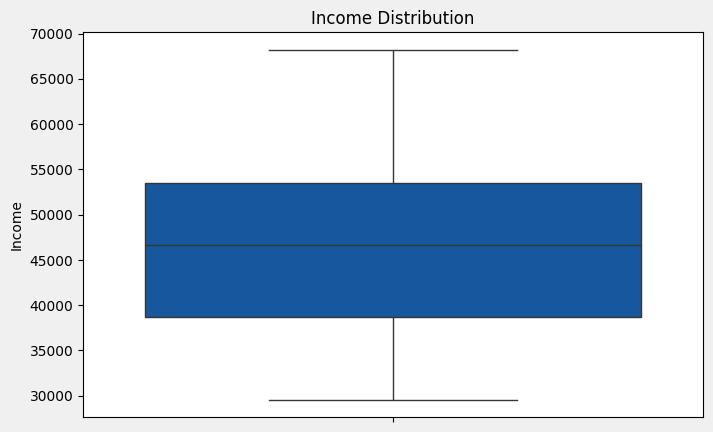

In [86]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Income'], color = '#0056B3')
plt.title('Income Distribution')
plt.show()

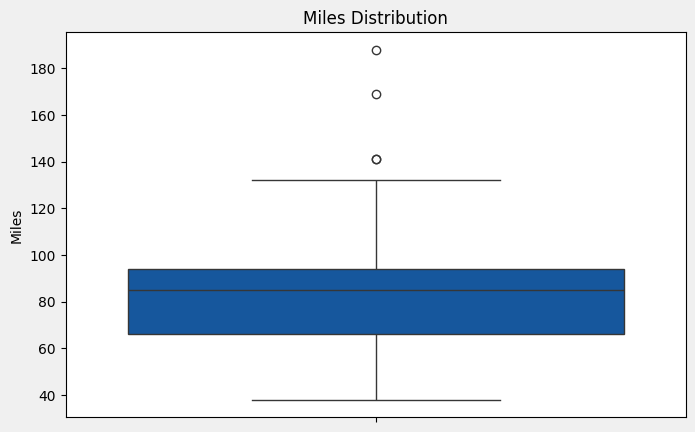

In [87]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP281_DF['Miles'], color = '#0056B3')
plt.title('Miles Distribution')
plt.show()

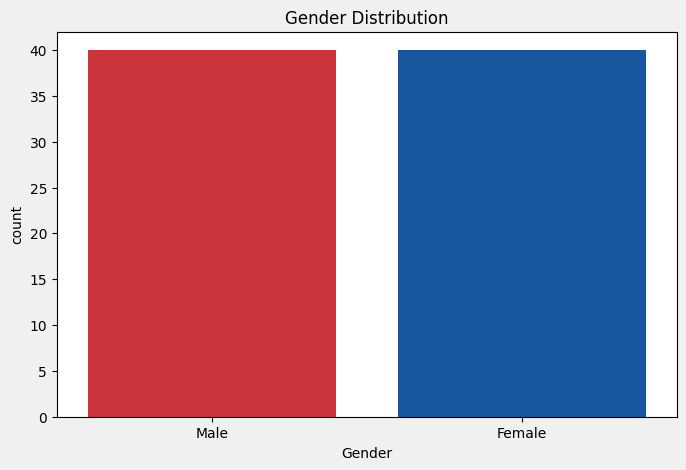

In [88]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP281_DF, x = 'Gender', hue = 'Gender', palette = aerofit_palette, legend = False)
plt.title('Gender Distribution')
plt.show()

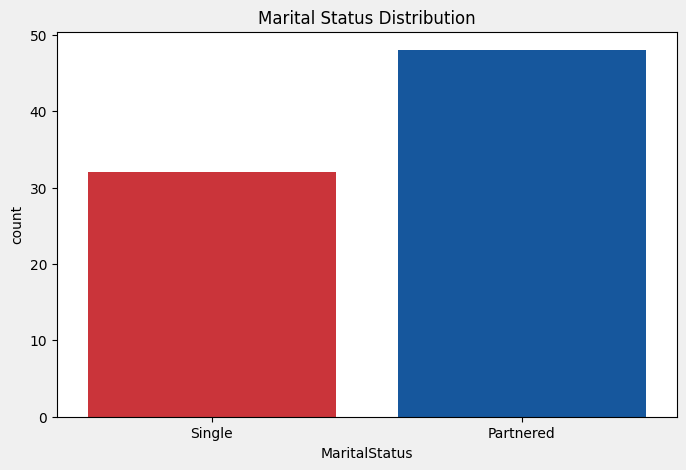

In [89]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP281_DF, x = 'MaritalStatus', hue = 'MaritalStatus', palette = aerofit_palette, legend = False)
plt.title('Marital Status Distribution')
plt.show()

---

#**CONCLUSION for KP281**

---


* Total Sales Volume : 80 units (44.4% of total dataset sales — the most popular model)

* Retail Price : $1,500

* Age Range : Primarily 18 to 35 years (with a tight clustering around 23–33)

* Gender Split : Equal distribution (50% Male / 50% Female)
 * Education : 12 to 16 years (typically high school graduates or college students/grads)

* Marital Status : More popular among Partnered individuals than Single individuals

* Annual Income : Generally below 60,000
(typically  ranging  from  30,000 to 55,000)

* Weekly Usage : Low to moderate usage (2 to 4 times per week)
 * Self-Rated Fitness : Score of 2 to 4 out of 5 (Beginner to intermediate fitness levels)
 * Expected Weekly Miles : 450 to 100 miles per week

**Key Insight for Your Analysis:**

The KP281 is the only model in the dataset that has an even gender split (40 male buyers and 40 female buyers).

In contrast, higher-end models like the KP781 are heavily dominated by male buyers.



---


# **Notable Findings for KP281:**


---


* **The Affordable Choice:**

The average income ($\sim \$46,418$) is the lowest among all three treadmill customer segments, indicating its strong market position as a budget-friendly option.

* **Standard Fitness Profiles:**

The mean self-rated fitness score is $2.96$ out of $5$, and the median usage is $3$ times a week. This shows that **the KP281 targets casual fitness enthusiasts** rather than elite athletes (who heavily opt for the KP781 model).


---



# **Customer Baseline Profile for KP481**

In [101]:
KP481_DF = aerofit[aerofit['Product'] == 'KP481']
KP481_DF.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
80,KP481,19,Male,14,Single,3,3,31836,64
81,KP481,20,Male,14,Single,2,3,32973,53
82,KP481,20,Female,14,Partnered,3,3,34110,106
83,KP481,20,Male,14,Single,3,3,38658,95
84,KP481,21,Female,14,Partnered,5,4,34110,212


In [91]:
KP481_DF.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000
mean,28.900000,15.116667,3.066667,2.90000,48973.650000,87.933333
std,6.645248,1.222552,0.799717,0.62977,8653.989388,33.263135
min,19.000000,12.000000,2.000000,1.00000,31836.000000,21.000000
25%,24.000000,14.000000,3.000000,3.00000,44911.500000,64.000000
50%,26.000000,16.000000,3.000000,3.00000,49459.500000,85.000000
75%,33.250000,16.000000,3.250000,3.00000,53439.000000,106.000000
max,48.000000,18.000000,5.000000,4.00000,67083.000000,212.000000


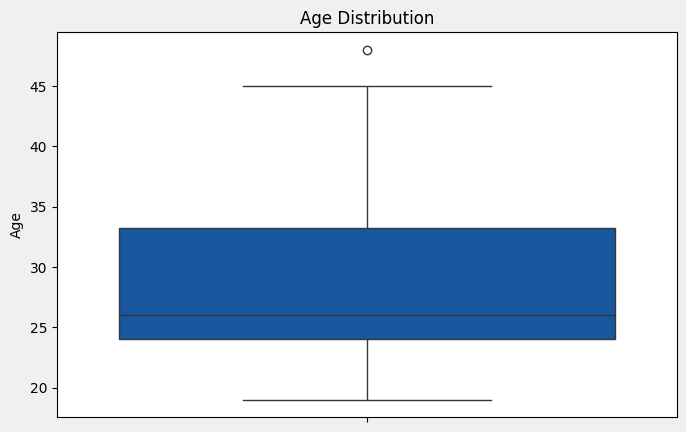

In [92]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Age'], color = '#0056B3')
plt.title('Age Distribution')
plt.show()

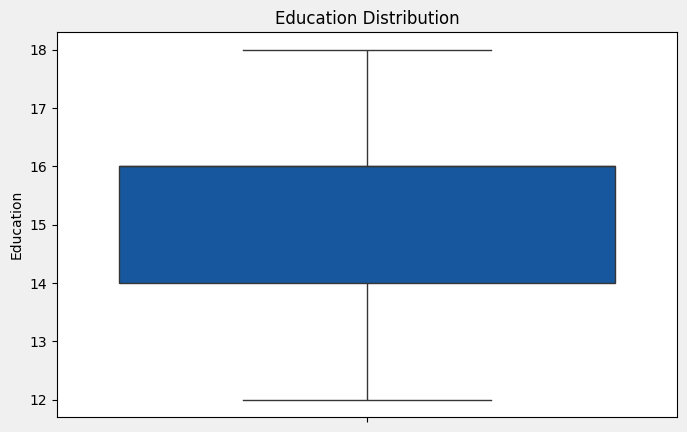

In [93]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Education'], color = '#0056B3')
plt.title('Education Distribution')
plt.show()

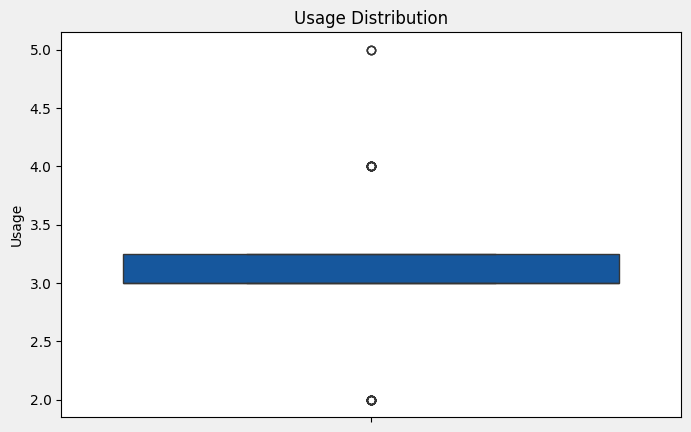

In [94]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Usage'], color = '#0056B3')
plt.title('Usage Distribution')
plt.show()

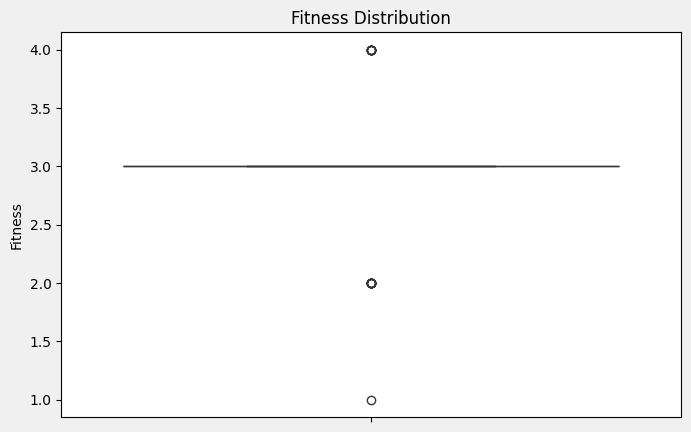

In [95]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Fitness'], color = '#0056B3')
plt.title('Fitness Distribution')
plt.show()

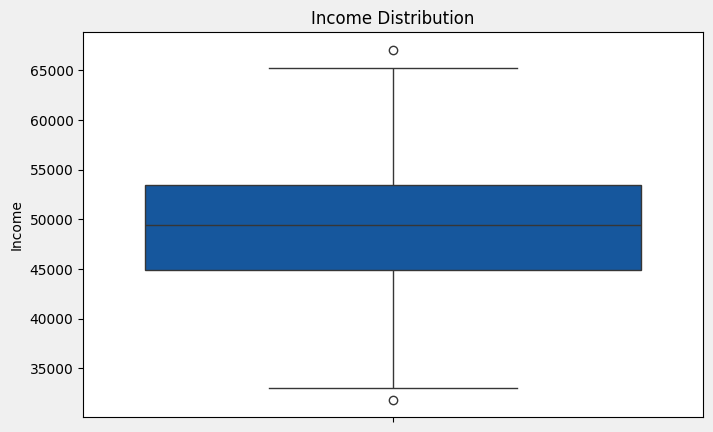

In [96]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Income'], color = '#0056B3')
plt.title('Income Distribution')
plt.show()

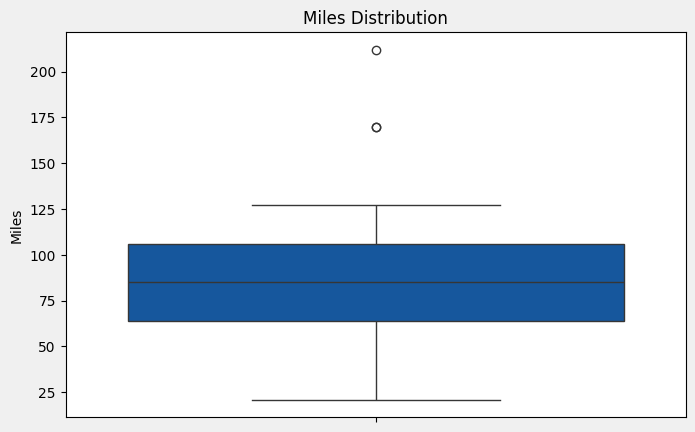

In [97]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP481_DF['Miles'], color = '#0056B3')
plt.title('Miles Distribution')
plt.show()

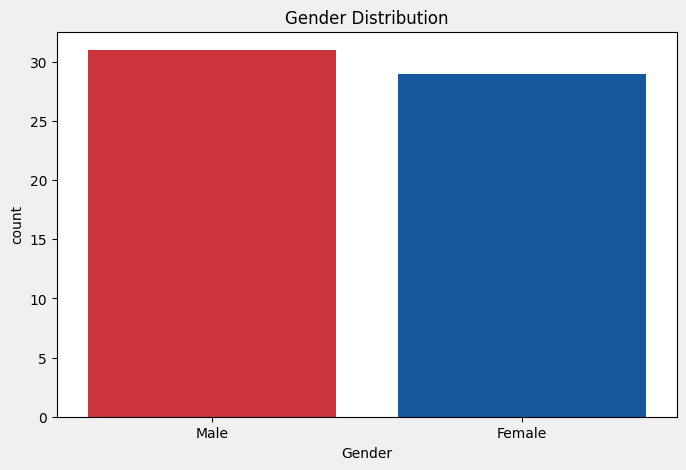

In [98]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP481_DF, x = 'Gender', hue = 'Gender', palette = aerofit_palette, legend = False)
plt.title('Gender Distribution')
plt.show()

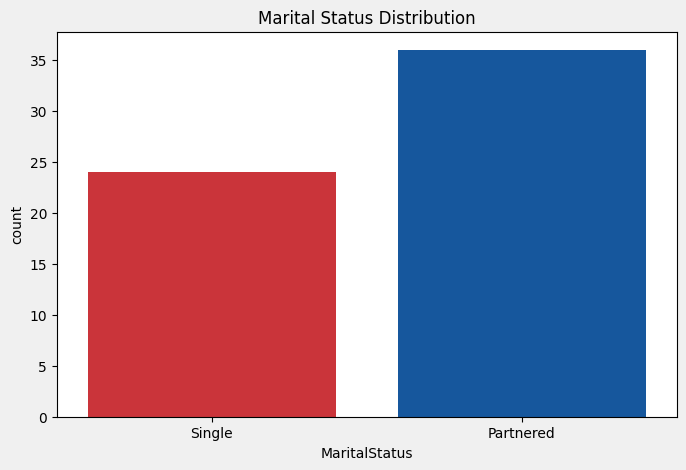

In [99]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP481_DF, x = 'MaritalStatus', hue = 'MaritalStatus', palette = aerofit_palette, legend = False)
plt.title('Marital Status Distribution')
plt.show()



---



# **Customer Baseline Profile for KP781**

In [105]:
KP781_DF = aerofit[aerofit['Product'] == 'KP781']
KP281_DF.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [108]:
KP781_DF.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000
mean,29.100000,17.325000,4.775000,4.625000,75441.57500,166.900000
std,6.971738,1.639066,0.946993,0.667467,18505.83672,60.066544
min,22.000000,14.000000,3.000000,3.000000,48556.00000,80.000000
25%,24.750000,16.000000,4.000000,4.000000,58204.75000,120.000000
50%,27.000000,18.000000,5.000000,5.000000,76568.50000,160.000000
75%,30.250000,18.000000,5.000000,5.000000,90886.00000,200.000000
max,48.000000,21.000000,7.000000,5.000000,104581.00000,360.000000


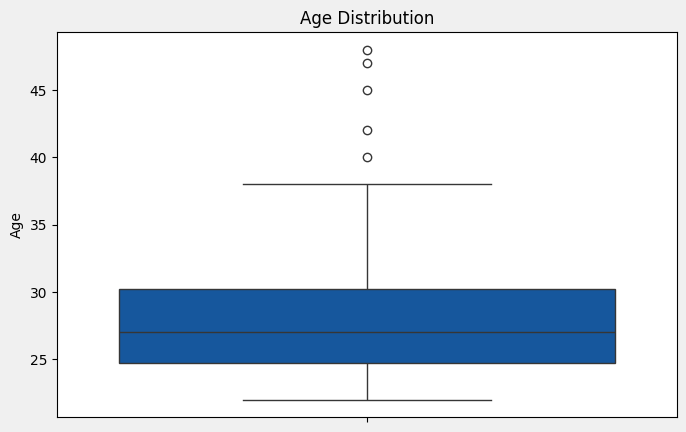

In [107]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Age'], color = '#0056B3')
plt.title('Age Distribution')
plt.show()

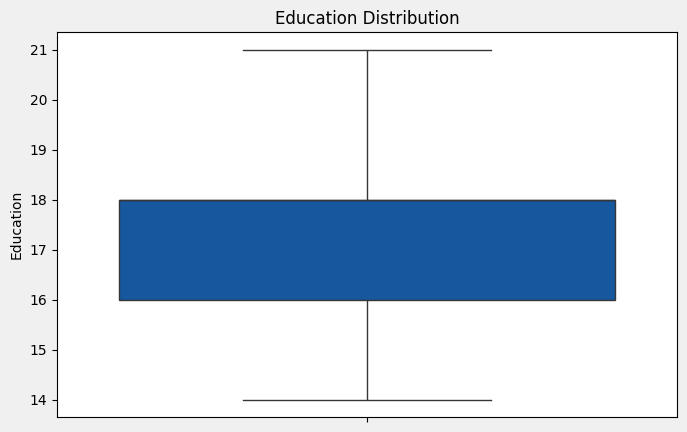

In [109]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Education'], color = '#0056B3')
plt.title('Education Distribution')
plt.show()

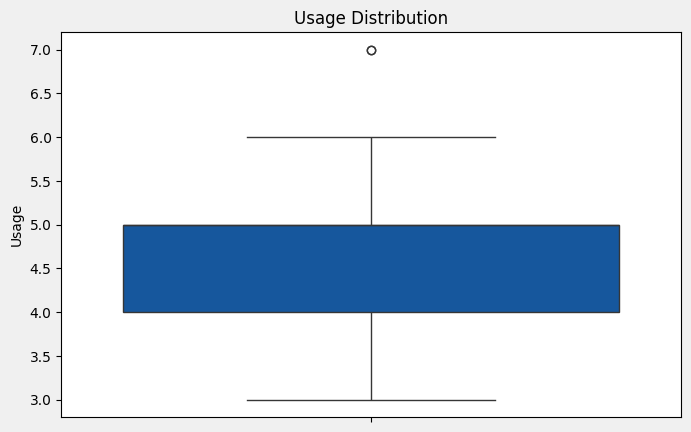

In [110]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Usage'], color = '#0056B3')
plt.title('Usage Distribution')
plt.show()

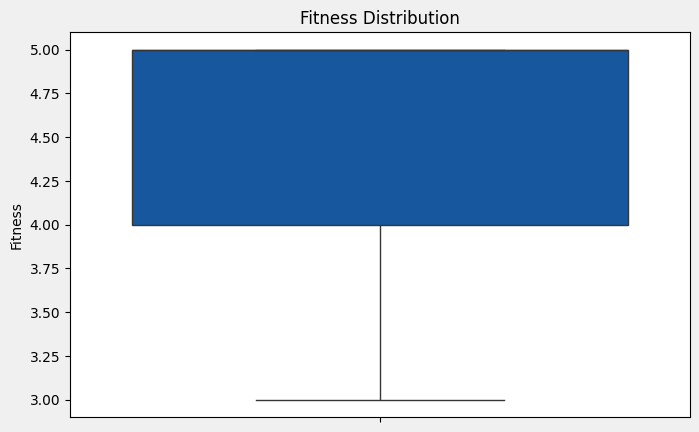

In [111]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Fitness'], color = '#0056B3')
plt.title('Fitness Distribution')
plt.show()

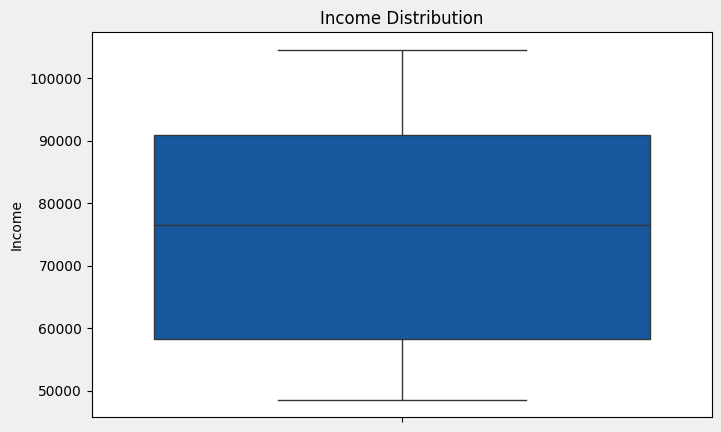

In [112]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Income'], color = '#0056B3')
plt.title('Income Distribution')
plt.show()

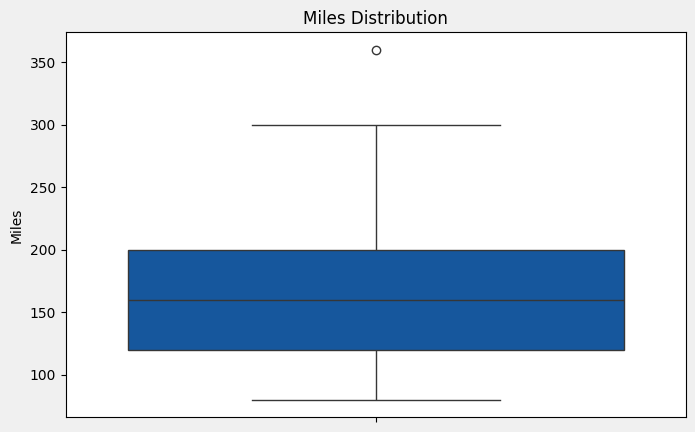

In [113]:
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.boxplot(KP781_DF['Miles'], color = '#0056B3')
plt.title('Miles Distribution')
plt.show()

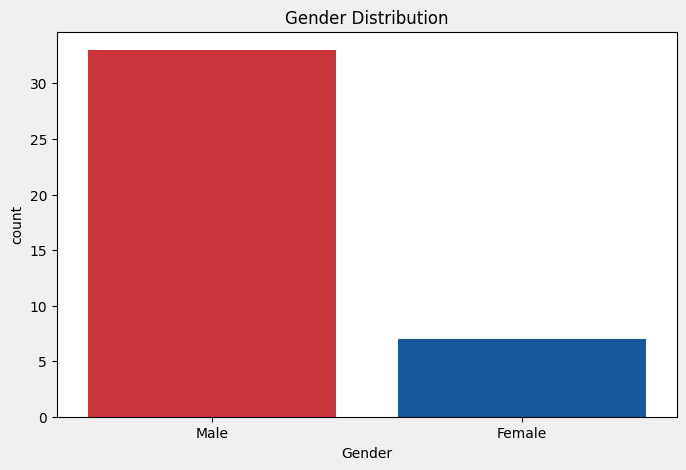

In [114]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP781_DF, x = 'Gender', hue = 'Gender', palette = aerofit_palette, legend = False)
plt.title('Gender Distribution')
plt.show()

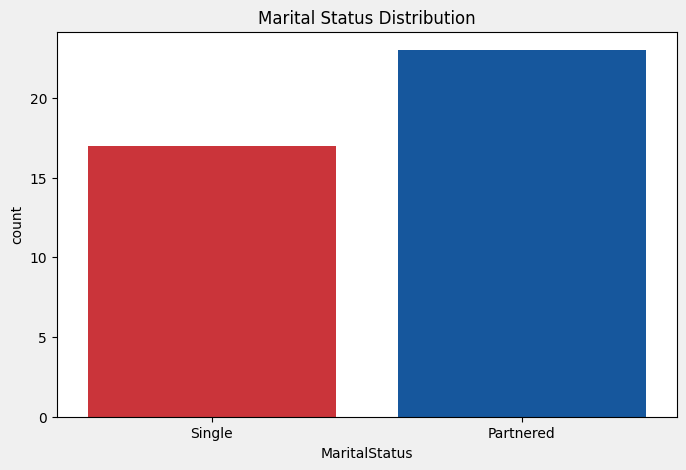

In [115]:
aerofit_palette = ['#E31B23', '#0056B3']
plt.figure(figsize=(8,5), facecolor='#F0F0F0')
sns.countplot(data = KP781_DF, x = 'MaritalStatus', hue = 'MaritalStatus', palette = aerofit_palette, legend = False)
plt.title('Marital Status Distribution')
plt.show()

# **Feature Engineering**